## **DataInputStream/DataOutputStream** reads/writes primitives & Strings 按固定格式写入/读取 基本类型（int, long, double, boolean…）和 String（readUTF/writeUTF）

### 	•	DataXxxStream：写/读的是“基本类型的字节表示（协议自己定）”


In [ ]:
DataOutputStream out = new DataOutputStream(new FileOutputStream("src/L09.txt"));
DataInputStream in = new DataInputStream(new FileInputStream("src/L09.txt"));

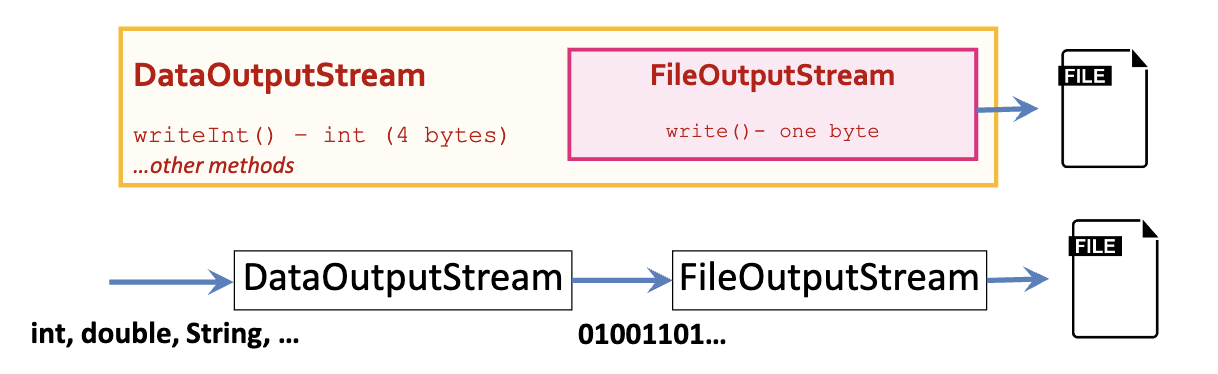
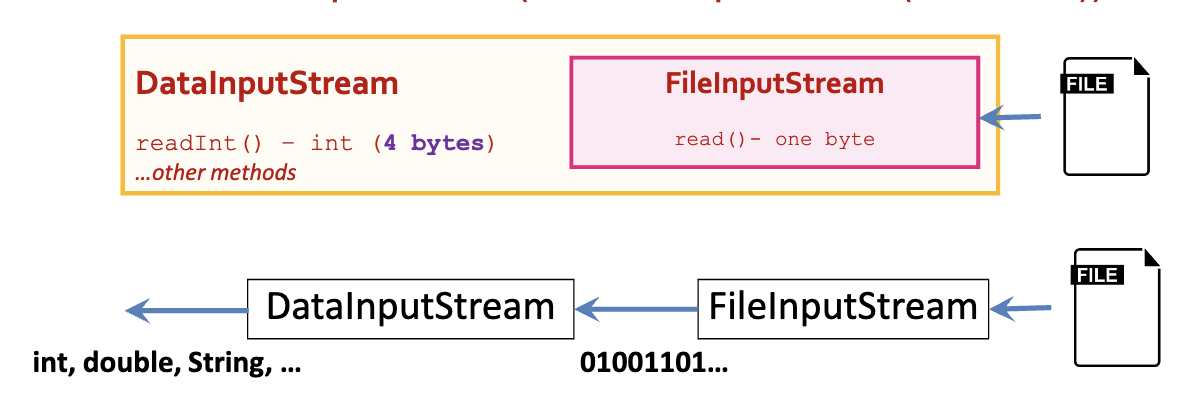

### Syntax

In [ ]:
writeBoolean(b:boolean):void
writeByte(v:int):void
writeShort(v:int):void
writeChar(v:int):void
writeInt(v:int):void
writeLong(v:long):void
writeFloat(v:float):void
writeDouble(v:double):void
writeChar(c:char):void
writeUTF(s:String):void

### 各个write function的字符占用(假设使用的是`DataOutput/InputStream`)
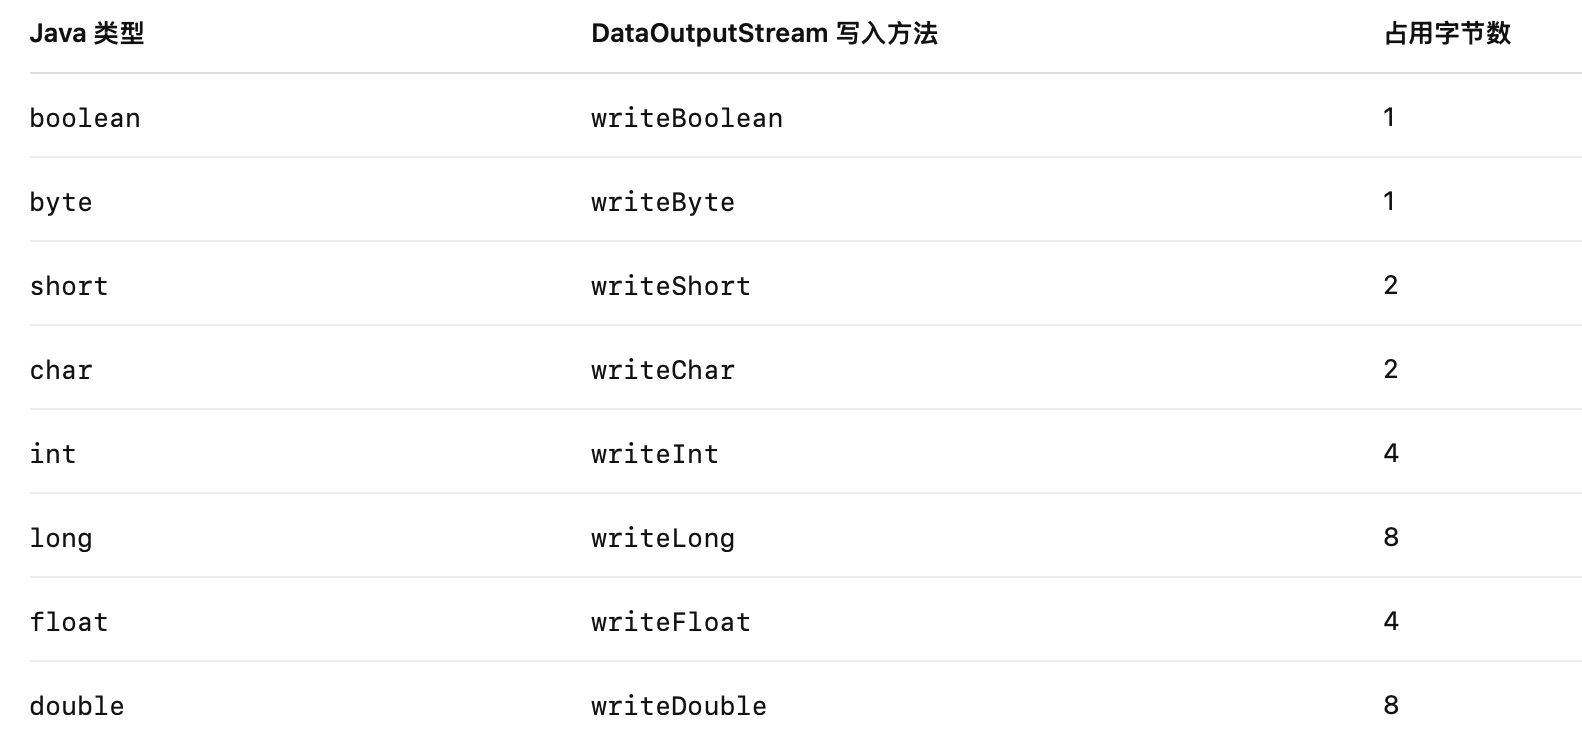
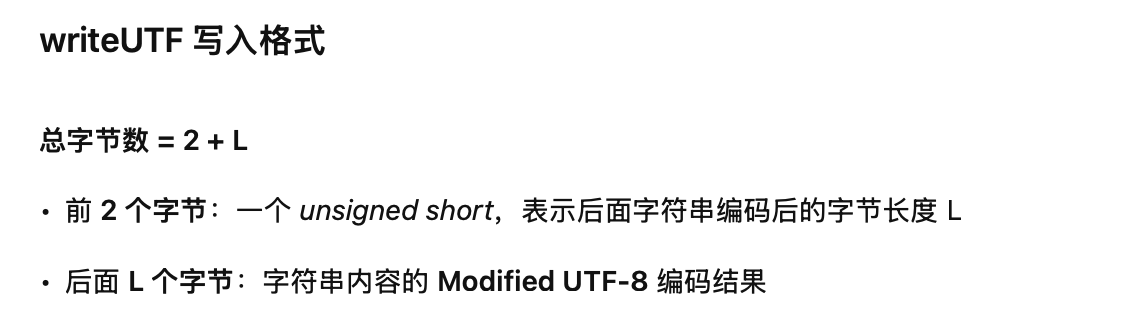
### 而在PrintWriter / FileWriter / BufferedWriter情况下因为是吧所有的转成字符串在输出所以按照字符大小来算
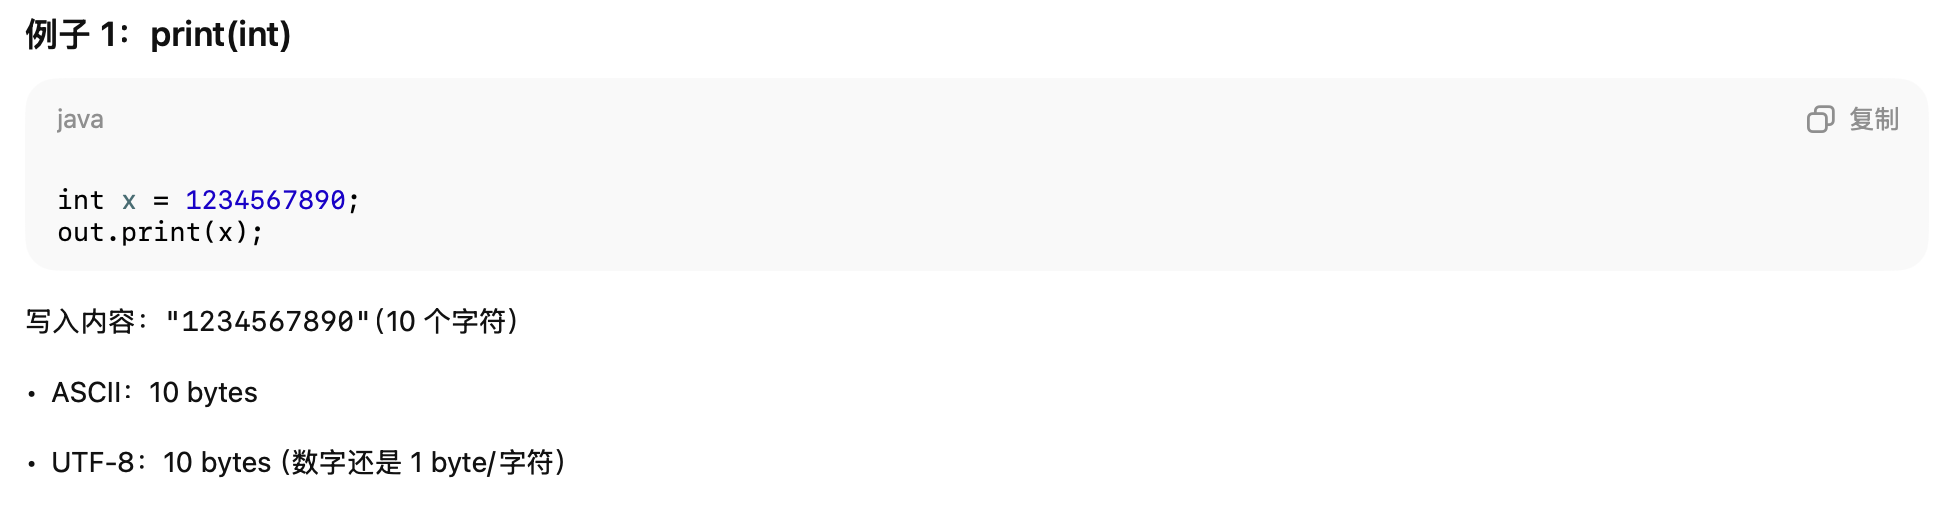
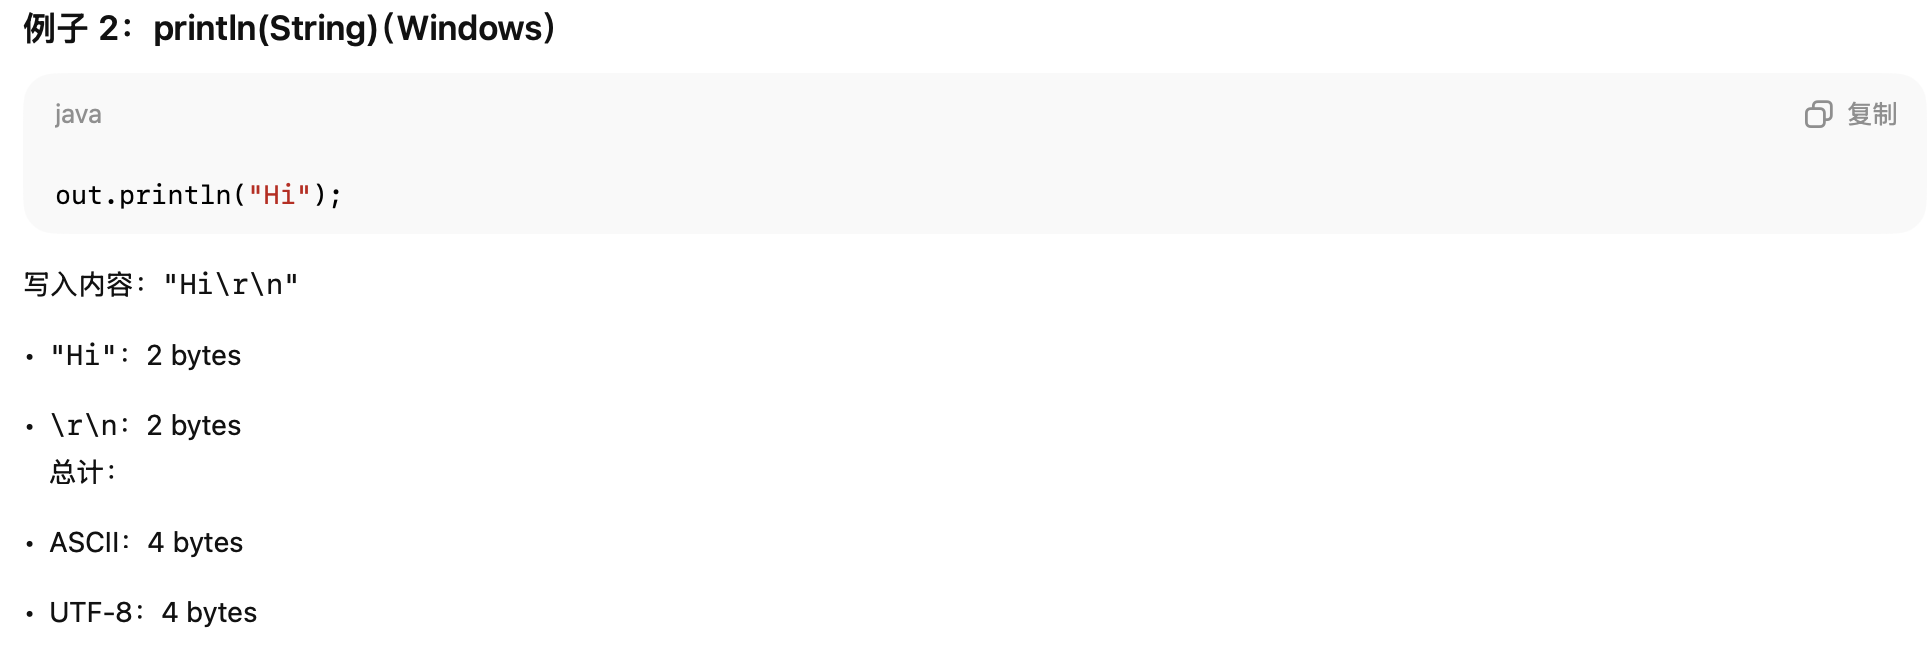
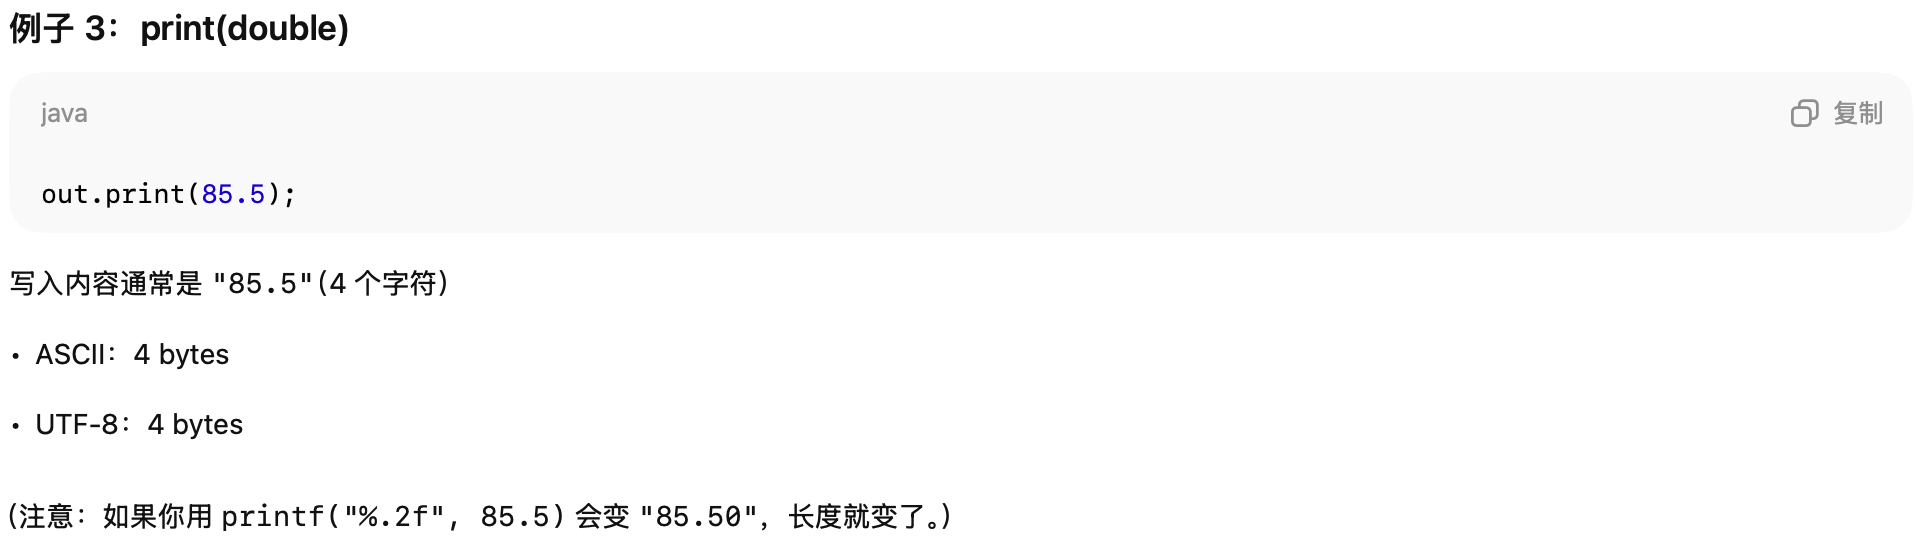

In [ ]:
readBoolean():boolean
readByte():byte
readShort():short
readChar():char
readInt():int
readLong():long
readFloat():float
readDouble():double
readChar():char
readUTF():String

## **ObjectInputStream/ObjectOutputStream** 对象序列化（Serialization），目的是保留对象及对象的一切功能

### ObjectXxxStream：写/读的是“Java 对象（带类型+引用关系）”

In [ ]:
ObjectOutputStream out = new ObjectOutputStream(new FileOutputStream("src/L09_object.txt"));
ObjectInputStream in = new ObjectInputStream(new FileInputStream("src/L09_object.txt"));

## `Serializable Interface` 是对于object类读取/写入是必不可少的东西，当使用Objectinput/outputStream是必须要提前申明或者使用try{}catch{}

## `transient` keyword，当可序列化对象里面有不可序列化数据时候使用**transit**可以是jvm忽略这个问题，也就是`暂时跳过这个代码`,所以一般输出为null

In [ ]:
serializable object contains non-serializable data field
class Engine { }                 // 没有 implements Serializable

class Robot implements Serializable {
    Engine e = new Engine();     // 这个字段就是 non-serializable data field
}

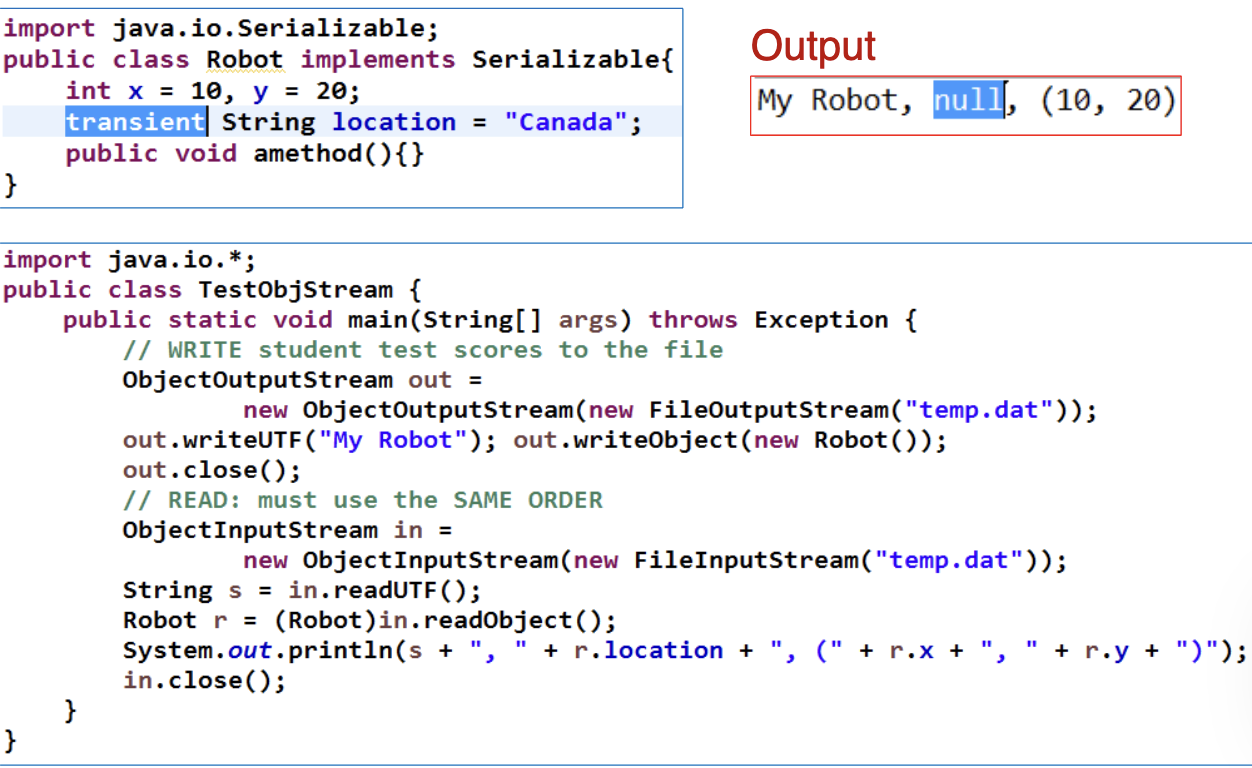
#### 这里String被使用了transient所以让jvm忽略这一段代码所以读取后得到的是null

In [ ]:
import java.io.*;

public class L10 {
    public static void main(String[] args) throws Exception {
        ObjectOutputStream out = new ObjectOutputStream(new FileOutputStream("src/L10.txt"));
        out.writeUTF("123");
        out.writeObject(new car());
        out.close();
        ObjectInputStream in = new ObjectInputStream(new FileInputStream("src/L10.txt"));
        String a = in.readUTF();
        car c = (car)in.readObject();//ClassNotFoundException
        System.out.println("UTF:"+a+" name:"+c.name+" x:"+c.x+" y:"+c.y);
    }
}

class engine{
    private double value,size;
    engine(){
        value=0.0;
        size=0.0;
    }
}
class car implements Serializable {
    int x=10,y=20;
    transient engine e = new engine();
    String name = "牛逼car";
}
------------------------------------------
UTF:123 name:牛逼car x:10 y:20